In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(host = "localhost",
                            username = "root",
                            password = "Alone@999",
                            database = "ecommerce")

cur = db.cursor()

# List all unique cities where customers are located

In [6]:
query = """ select
distinct customer_city
from
customers """

cur.execute(query)

data = cur.fetchall()

data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# Count the number of orders placed in 2017.

In [7]:
query1 = """ select
count(order_id)
from orders
where
year(order_purchase_timestamp) = 2017 """

cur.execute(query1)

data = cur.fetchall()

"Total order placed in 2017 are:", data[0][0]

('Total order placed in 2017 are:', 90202)

# Find the total sales per category.

In [9]:
query1 = """ select 
products.product_category as category,
round(sum(payments.payment_value),2) as sales

from 
products
join
order_items on products.product_id = order_items.product_id
join
payments on payments.order_id = order_items.order_id
group by
category"""

cur.execute(query1)

data = cur.fetchall()
df = pd.DataFrame(data)
df

,0,1
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


# Calculate the percentage of orders that were paid in installments.

In [10]:
query1 = """ select sum(case when payment_installments >=1 then 1
else 0 end)/ count(*)*100 from payments"""

cur.execute(query1)

data = cur.fetchall()

"The percentage of Orders That were Paid in Installments", data

('The percentage of Orders That were Paid in Installments',
 [(Decimal('99.9981'),)])

# Count the number of customers from each state. 

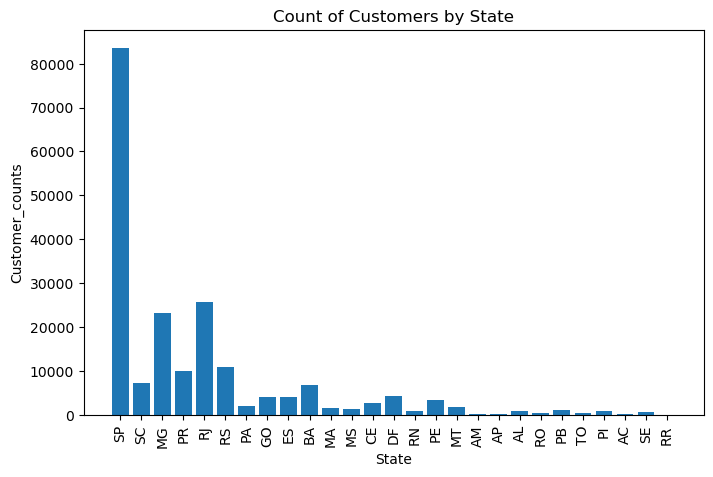

In [20]:
query = """ select customer_state ,count(customer_id)
from
customers
group by
customer_State"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["State", "Customer_counts"])

plt.figure(figsize= (8,5))

plt.bar(df["State"], df["Customer_counts"])

df =  df.sort_values(by = "Customer_counts", ascending= False)

plt.xticks(rotation = 90)

plt.xlabel("State")

plt.ylabel("Customer_counts")

plt.title("Count of Customers by State")

plt.show()

# Calculate the number of orders per Month in 2018.

<function matplotlib.pyplot.show(close=None, block=None)>

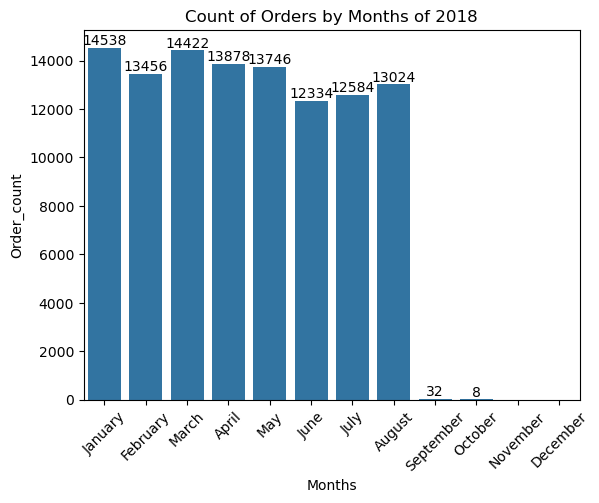

In [24]:
query = """ select
monthname(order_purchase_timestamp) months, count(order_id) as order_count
from
orders where year(order_purchase_timestamp) = 2018
group by
months"""

cur.execute(query)

data = cur.fetchall()

data

df =pd.DataFrame(data, columns = ["Months", "Order_count"])
seq = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

ax = sns.barplot(x = df["Months"],y =  df["Order_count"], data  = df , order = seq)
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months of 2018")
plt.show()

# Find the average number of products per order, grouped by customer city.

In [23]:
query = """ with count_per_order as
(select orders.order_id, orders.customer_Id, count(order_items.order_id) as oc
from ecommerce.orders join ecommerce.order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)
select customers.customer_city, round(avg(count_per_order.oc),2)
from ecommerce.customers join count_per_order
on customers.customer_id = count_per_order.customer_id 
group by customers.customer_city;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns=["Customer Citys", "Average products/Orders"])
df.head(10)

,Customer Citys,Average products/Orders
0,treze tilias,2.55
1,indaial,2.23
2,sao jose dos campos,2.28
3,sao paulo,2.31
4,porto alegre,2.35
5,santos,2.32
6,sao francisco do sul,2.47
7,sao vicente,2.18
8,joinville,2.21
9,sao vendelino,2.00


# Calculate the percentage of total revenue contributed by each product category.

In [25]:
query1 = """ select 
products.product_category as category,
round((sum(payments.payment_value)/ (select sum(payment_value) from ecommerce.payments))*100,2)
as sales_percentage

from 
ecommerce.products
join
ecommerce.order_items on products.product_id = order_items.product_id
join
ecommerce.payments on payments.order_id = order_items.order_id
group by
category order by sales_percentage desc """

cur.execute(query1)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["Category","%Percentage Distribution"])
df

,Category,%Percentage Distribution
0,bed table bath,10.70
1,HEALTH BEAUTY,10.35
2,computer accessories,9.90
3,Furniture Decoration,8.93
4,Watches present,8.93
...,...,...
69,House Comfort 2,0.01
70,cds music dvds,0.01
71,PC Gamer,0.01
72,Fashion Children's Clothing,0.00


# Identify the correlation between product price and the number of times a product has been purchased.

In [27]:
import numpy as np

query = """select products.product_category,
                count(order_items.product_id),
                round(avg(order_items.price),2)
                from products join order_items
                on products.product_id = order_items.product_id
                group by products.product_category;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns=["Products","order_count","Price"])

arr1 = df["order_count"]
arr2 = df["Price"]

a = np.corrcoef([arr1,arr2])

print("The correlation between price and product has been purchased:", a[0][1])

The correlation between price and product has been purchased: -0.10631514167157562


# Calculate the total revenue generated by each seller, and rank them by revenue.

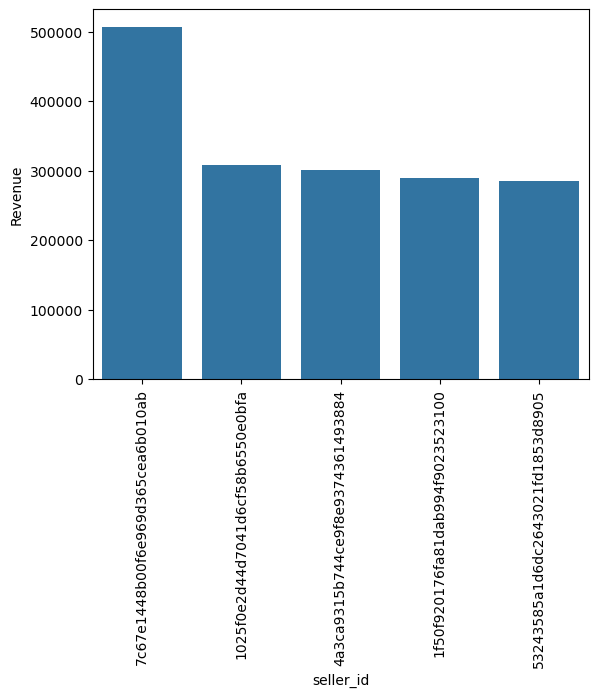

In [30]:
query = """select *, dense_rank()over(order by revenue desc) as dr from
(select
order_items.seller_id,
sum(payments.payment_value) as revenue
From 
order_items join payments
on 
order_items.order_id = payments.order_id
group by
order_items.seller_id) as a;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns=['seller_id','Revenue', 'Rank'])
# df.head()
ax = sns.barplot(x = 'seller_id', y = 'Revenue', data = df.head())
plt.xticks(rotation = 90)
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [32]:
query = """ select
customer_id,
order_purchase_timestamp, payment,
avg(payment)
over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select 
orders.customer_id,
orders.order_purchase_timestamp,
payments.payment_value as payment
from 
payments join orders
on
payments.order_id = orders.order_id) as sq;"""

cur.execute(query)

data = cur.fetchall()

data
df = pd.DataFrame(data, columns=['customer_id', 'order_purchase_timestamp','Average_payment','Moving Average'])
df

,customer_id,order_purchase_timestamp,Average_payment,Moving Average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
3,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
4,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
...,...,...,...,...
207767,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
207768,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000
207769,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000
207770,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


# Calculate the cumulative sales per month for each year. 

In [36]:
query = """select 
years, months, payment, sum(payment) 
over(order by years, months) as cumulative_sales
from
(select 
year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment
from 
orders join payments
on
orders.order_id = payments.order_id
group by 
years, months order by years , months)as a;"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data, columns=['Years', 'Months', 'Payments', 'Sum_of_payments'])
df

,Years,Months,Payments,Sum_of_payments
0,2016,9,504.48,504.48
1,2016,10,118180.96,118685.44
2,2016,12,39.24,118724.68
3,2017,1,276976.08,395700.76
4,2017,2,583816.02,979516.78
5,2017,3,899727.20,1879243.98
6,2017,4,835576.06,2714820.04
7,2017,5,1185837.64,3900657.68
8,2017,6,1022552.76,4923210.44
9,2017,7,1184765.84,6107976.28


# Calculate the year-over-year growth rate of total sales.

In [37]:
query = """with a as(select 
year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment
from 
orders join payments
on
orders.order_id = payments.order_id
group by 
years order by years)
select years, ((payment - lag(payment, 1) over(order by years)) /
lag(payment, 1) over(order by years))*100 as Pervious_year from a"""

cur.execute(query)

data = cur.fetchall()
df =pd.DataFrame(data, columns = ["years","yoy % growth "])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [39]:
query = """with a as
(select customers.customer_id,
MIN(orders.order_purchase_timestamp) as frist_order
from
customers join orders
on customers.customer_id =  orders.customer_id
group by 
customers.customer_id),

b as(select a.customer_id, count(distinct orders.order_purchase_timestamp) as next_order
from a join orders on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > frist_order
and orders.order_purchase_timestamp < date_add(frist_order, interval 6 month)
group by a.customer_id)

select 100 * (count(distinct a.customer_id)/ count(distinct b.customer_id))
from a left join b on a.customer_id  = b.customer_id
;"""

cur.execute(query)

data = cur.fetchall()
print(data, "Customer Retention Rate within 6 months")

[(None,)] Customer Retention Rate within 6 months


# Identify the top 3 customers who spent the most money in each year.

<function matplotlib.pyplot.show(close=None, block=None)>

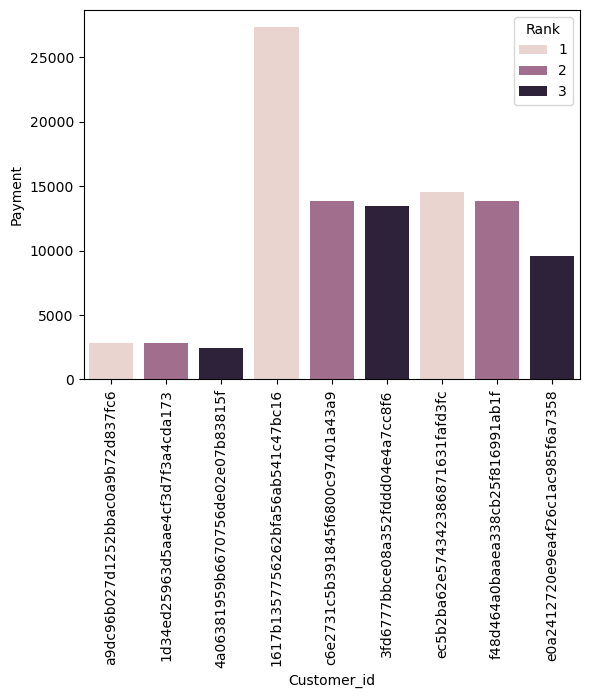

In [40]:
query = """select years, customer_id, payment, Ranks from
(select year(order_purchase_timestamp) as Years,
orders.customer_id,
sum(payments.payment_value) as payment,
dense_rank()
over(partition by year(order_purchase_timestamp)
order by sum(payments.payment_value)desc) as Ranks
from orders join payments
on payments.order_id = orders.order_id
group by year(order_purchase_timestamp),
orders.customer_id) as SUB
where Ranks <=3;"""


cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns=["Year","Customer_id","Payment","Rank"])
df
sns.barplot(x = "Customer_id",y = "Payment" ,data = df,hue = "Rank")
plt.xticks(rotation = 90)
plt.show()